# Q1. How should ClinVar missense variants be split for reliable evaluation on previously unseen genes?

**Earlier broad-SNV run.** The project now targets missense variants only; the code and recorded outputs below have not been rebuilt and are not missense-only results.

Start with Q0’s **346,038 eligible SNVs** and build a reproducible **5,000-variant pilot**. [Dependencies](../requirements.txt) · [Implementation](src/q1.py) · CPU only.

In [1]:
from src import q1
q1.settings()

Q0 cohort → 5,000-variant pilot → frozen training / validation groups
1,024-base windows · seed 42 · approximately 70% / 30% · CPU only
data/clinvar-train-pilot.vcf = training; data/clinvar-test-pilot.vcf = validation (no separate test stage).


## Eligibility filters inherited from Q0

Q1 rebuilds the eligible cohort from the pinned **2026-09-05 GRCh38 ClinVar VCF** using [Q0’s filtering function](src/q0.py). The filters below are applied in order; counts describe the recorded run.

| Step | Records retained |
| --- | ---: |
| All input records | 4,469,028 |
| Exclude duplicate variant keys with inconsistent annotations | 4,469,028 |
| Keep chromosomes **1–22, X and Y** | 4,465,847 |
| Keep single-base **A/C/G/T substitutions**, with REF different from ALT | 4,157,786 |
| Exclude germline classification conflicts | 3,998,278 |
| Keep accepted benign or pathogenic classifications | 1,486,095 |
| Require **at least two review stars** | 346,039 |
| Require **at least one usable gene ID** | 346,038 |
| Collapse consistent duplicate variant keys | **346,038** |

Accepted `CLNSIG` values are exactly `Benign`, `Likely_benign`, `Benign/Likely_benign`, `Pathogenic`, `Likely_pathogenic` and `Pathogenic/Likely_pathogenic`. These map to two classes: benign and pathogenic. Uncertain, missing and other classifications are excluded. Conflict evidence means a populated `CLNSIGCONF`, conflict text in `CLNSIG`, or conflict text in `CLNREVSTAT` other than `no_conflicts`.

The review threshold accepts `criteria_provided,_multiple_submitters,_no_conflicts` (2 stars), `reviewed_by_expert_panel` (3) and `practice_guideline` (4). A usable gene is a `GENEINFO` entry with a nonempty symbol and a positive numeric NCBI Gene ID; all usable IDs are retained. Duplicate keys are defined by chromosome, position, REF and ALT. Keys with inconsistent annotations are excluded entirely; consistent duplicates are collapsed while preserving contributing source IDs. Neither duplicate step removed records in this run.

These rules define eligibility using clinical labels and review annotations. Sampling and split assignment below use no labels. See the [recorded filter counts](results/q0/filter_counts.csv).

## Group the full cohort

Join variants sharing genes, loci, source IDs or overlapping **1,024-base windows**. Connections are transitive, including through variants outside the pilot. Grouping keeps related variants in the same split and does not remove records.

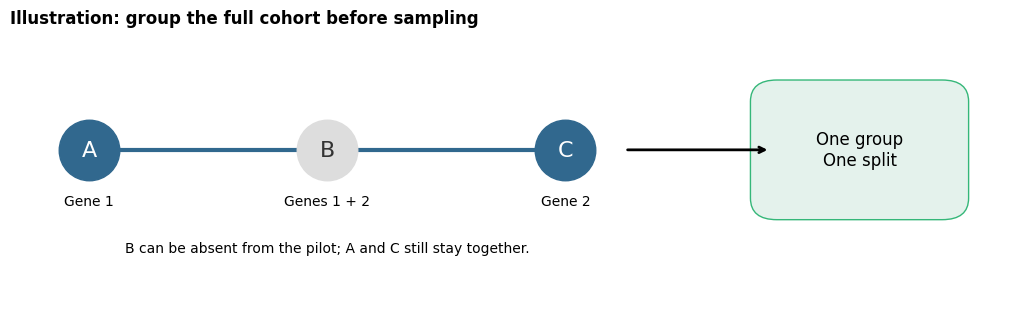

In [2]:
q1.show_grouping()

## Sample and freeze

Select **5,000 of the 346,038 eligible variants** by taking the lowest `SHA256(42:sample:variant_key)` hashes. This deterministic sample uses seed **42**, without label stratification or class balancing.

For each sampled variant, verify REF against the pinned GRCh38 FASTA and extract its **1,024-base reference and alternate windows**. Exclude a variant if its window extends beyond a chromosome boundary (`truncated_window`) or contains any base outside A/C/G/T (`non_ACGT_window`). Exclusions are made **without replacement**. A REF mismatch stops execution. The recorded run has **zero sequence exclusions**, so all **5,000 variants** remain; see the [sequence exclusion log](results/q1/sequence_exclusions.csv).

Merge groups with identical reference or alternate contexts, including reverse complements. Assign whole groups to **70% training / 30% validation** using a fixed hash with seed **42**. Assignment uses no labels.

In [3]:
q1.run_checks()
pilot, sequences = q1.prepare()

17 split and sequence integrity tests passed.


Preparing the full Q0 cohort from the verified VCF…


Read 500,000 records


Read 1,000,000 records


Read 1,500,000 records


...

Read 2,500,000 records


Read 3,000,000 records


Read 3,500,000 records


Read 4,000,000 records


5,000 sampled variants retained; 4 leakage check groups passed.


## What each split is for

**Training** fits scaling and classifiers. **Validation** chooses settings and compares models. There is no separate test stage. Genes are disjoint; each variant’s reference and alternate windows stay together. Different group sizes make the percentages approximate.

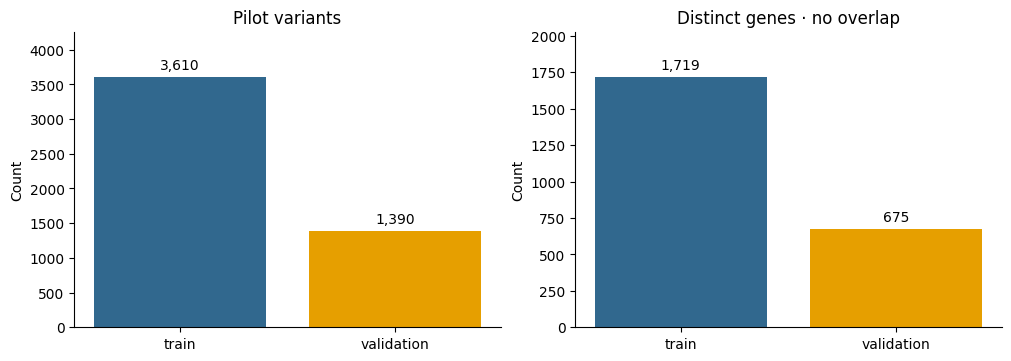

Whole groups are assigned by a fixed hash. Different group sizes make the proportions approximate.


,variants,components,genes,percent,purpose,vcf
split,,,,,,
train,3610,1436,1719,72.2,Fit scaling and classifiers,clinvar-train-pilot.vcf
validation,1390,559,675,27.8,Choose settings and compare models,clinvar-test-pilot.vcf


,variant_key,gene_ids,start,end,component,split
0,GRCh38:17:80108705:G:A,2548,80108192,80109216,GRCh38:17:80036614:C:A,train
1,GRCh38:20:63355968:G:A,1137|126863087,63355455,63356479,GRCh38:20:63346204:G:A,train
2,GRCh38:8:1771342:G:A,2055,1770829,1771853,GRCh38:8:1763883:C:T,train
3,GRCh38:5:148114367:A:G,11005,148113854,148114878,GRCh38:5:148063797:G:A,train
4,GRCh38:2:178574019:G:A,7273|100506866,178573506,178574530,GRCh38:2:178525940:A:G,validation
5,GRCh38:1:241504238:A:G,2271,241503725,241504749,GRCh38:1:241497858:T:C,train
6,GRCh38:1:109296811:A:G,343263,109296298,109297322,GRCh38:1:109294170:G:C,train
7,GRCh38:22:19766666:C:T,6899,19766153,19767177,GRCh38:22:19759519:C:T,train
8,GRCh38:21:43418516:C:T,150094,43418003,43419027,GRCh38:21:43416774:A:C,train
9,GRCh38:6:117706982:A:G,116150,117706469,117707493,GRCh38:6:117675655:T:C,validation


In [4]:
q1.show_splits(pilot)

[Pilot training VCF](../data/clinvar-train-pilot.vcf) · [Pilot validation VCF](../data/clinvar-test-pilot.vcf)

These are **pilot files** containing **5,000 variants in total**: 3,610 in `clinvar-train-pilot.vcf` (training) and 1,390 in `clinvar-test-pilot.vcf` (validation). They contain the sampled subset of Q0’s eligible cohort and fix membership for reproducing the earlier pilot experiment; clinical annotations supply labels only.

[Pilot manifest](results/q1/split_manifest.csv) · [Full-cohort groups](results/q1/full_cohort_groups.csv.gz) · [Split protocol](results/q1/protocol.json)

Checks cover recorded relationships and exact DNA contexts. Homology, shared patients and pretraining overlap remain unresolved. [Q2](Q2-evo2-classifier.ipynb) consumes these frozen inputs.

## Conclusion

The earlier broad-SNV pilot contains **3,610 training** and **1,390 validation variants**, with **no shared genes between partitions**. Grouping before sampling keeps recorded relationships and DNA contexts together. The two pilot VCFs freeze this split for reproducing the earlier experiment; validation supports development, with no independent final test estimate.

A missense-only split is not yet established here; retain existing assignments when defining the narrower inputs.